# Imports

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the images

In [23]:
def load_images(left_path: str, right_path: str):
   
    img1 = cv2.imread(left_path)
    img2 = cv2.imread(right_path)
    
    if img1 is None or img2 is None:
        raise ValueError("Error: Could not read images. Check file formats and integrity.")
    return img1, img2

# Find the features that matches using 
# Sift (detect the features)
# flann (match the features)

In [24]:
def find_feature_matches(img1: np.ndarray, img2: np.ndarray, ratio_threshold: float = 0.7):
    """Detects SIFT features and finds matches using FLANN."""
    
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()
    kp1, des1 = sift.detectAndCompute(gray1, None)
    kp2, des2 = sift.detectAndCompute(gray2, None)

    flann = cv2.FlannBasedMatcher({"algorithm": 1, "trees": 5}, {"checks": 50})
    matches = flann.knnMatch(des1, des2, k=2)

    # Lowe's ratio test
    good_matches = [m for m, n in matches if m.distance < ratio_threshold * n.distance]
    
    return kp1, kp2, good_matches

# Mapping using homography

In [25]:
def compute_homography(kp1, kp2, matches):
    """Computes the homography matrix to map img2 to img1."""
    if len(matches) < 4:
        raise ValueError(f"Not enough good matches found ({len(matches)}). Try photos with more overlap.")

    src = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(dst, src, cv2.RANSAC, 5.0)
    
    if H is None:
        raise RuntimeError("Homography calculation failed.")
        
    return H

# Blending

In [26]:
def warp_and_blend(img1: np.ndarray, img2: np.ndarray, H: np.ndarray, blend_alpha: float = 0.5) -> np.ndarray:
    """Warps img2 into img1's perspective and blends them together."""
    w_out = img1.shape[1] + img2.shape[1]
    h_out = max(img1.shape[0], img2.shape[0])

    warped = cv2.warpPerspective(img2, H, (w_out, h_out))

    img1_padded = np.zeros((h_out, w_out, 3), dtype=np.uint8)
    img1_padded[0:img1.shape[0], 0:img1.shape[1]] = img1

    mask1   = (img1_padded.sum(axis=2) > 0).astype(np.float32)
    mask2   = (warped.sum(axis=2) > 0).astype(np.float32)
    overlap = (mask1 * mask2)

    canvas = np.zeros_like(img1_padded)
    
    for c in range(3):
        channel = img1_padded[:, :, c].copy()
        # Add non-overlapping parts of img2
        channel = np.where((mask2 > 0) & (mask1 == 0), warped[:, :, c], channel)
        # Blend overlapping parts
        channel = np.where(overlap > 0, 
        img1_padded[:, :, c] * (1 - blend_alpha) + warped[:, :, c] * blend_alpha, 
        channel)
        canvas[:, :, c] = channel
        
    return canvas

# Remove the border that apperes after blending 

In [17]:
def crop_black_borders(image: np.ndarray) -> np.ndarray:
    """Crops empty black space from the stitched canvas."""
    gray_canvas = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh   = cv2.threshold(gray_canvas, 1, 255, cv2.THRESH_BINARY)
    x, y, w, h  = cv2.boundingRect(thresh)
    return image[y:y+h, x:x+w]

# Test

In [18]:
def stitch_images(left_img_path: str, right_img_path: str, output_path: str = None, 
                  ratio_threshold: float = 0.7, blend_alpha: float = 0.5) -> np.ndarray:
    try:
        # 1. Load
        img1, img2 = load_images(left_img_path, right_img_path)
        
        # 2. Features
        kp1, kp2, matches = find_feature_matches(img1, img2, ratio_threshold)
        
        # 3. Homography
        H = compute_homography(kp1, kp2, matches)
        
        # 4. Warp & Blend
        canvas = warp_and_blend(img1, img2, H, blend_alpha)
        
        # 5. Crop
        panorama = crop_black_borders(canvas)
        
        # 6. Save
        if output_path:
            cv2.imwrite(output_path, panorama)
            print(f"✓ Panorama saved successfully to: {output_path}")
            
        return panorama
        
    except Exception as e:
        print(f"Stitching failed: {e}")
        return None

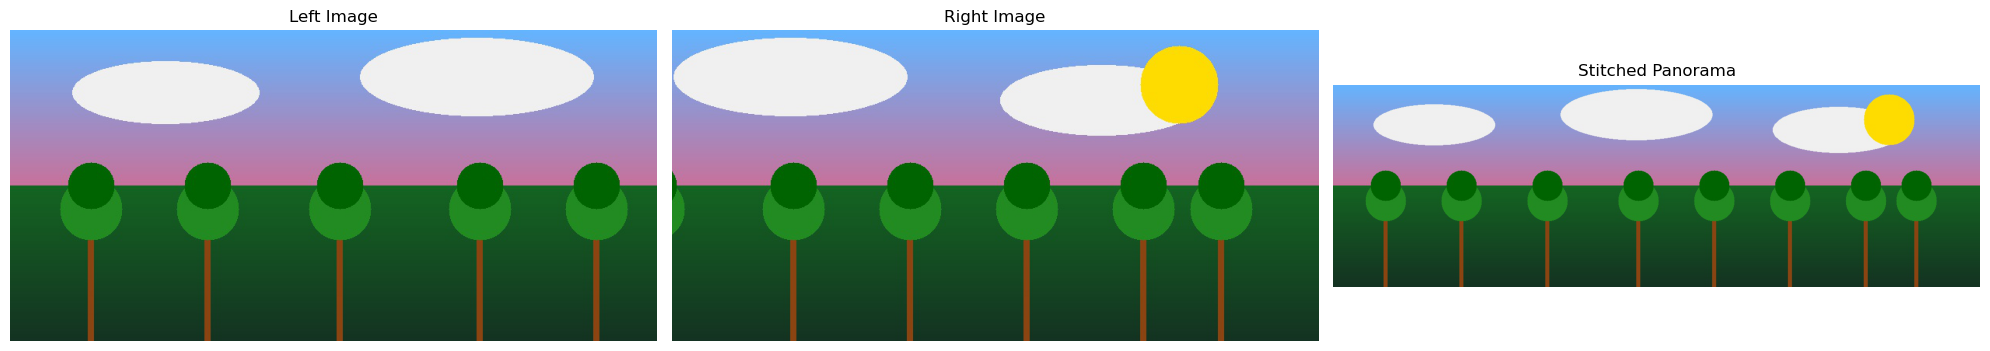

In [32]:
try:
    # 1. Run the pipeline
    img_left, img_right = load_images('Left.jpg', 'Right.jpg')
    k1, k2, matched_points = find_feature_matches(img_left, img_right)
    H_matrix = compute_homography(k1, k2, matched_points)
    raw_panorama = warp_and_blend(img_left, img_right, H_matrix)
    final_panorama = crop_black_borders(raw_panorama)

    # 2. Convert BGR to RGB for Matplotlib
    img_left_rgb = cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB)
    img_right_rgb = cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB)
    panorama_rgb = cv2.cvtColor(final_panorama, cv2.COLOR_BGR2RGB)

    # 3. Create the Plot
    plt.figure(figsize=(20, 10))

    # Plot Left Image
    plt.subplot(1, 3, 1)
    plt.imshow(img_left_rgb)
    plt.title('Left Image')
    plt.axis('off')

    # Plot Right Image
    plt.subplot(1, 3, 2)
    plt.imshow(img_right_rgb)
    plt.title('Right Image')
    plt.axis('off')

    # Plot Final Result
    plt.subplot(1, 3, 3)
    plt.imshow(panorama_rgb)
    plt.title('Stitched Panorama')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")